In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
import networkx as nx
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120 #resolution
matplotlib.rcParams['figure.figsize'] = (8,6) #figure size
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
color = sns.color_palette()

In [11]:
csv_users = pd.read_csv("/content/drive/MyDrive/datos proyecto final csv/users.csv")
csv_movies = pd.read_csv("/content/drive/MyDrive/datos proyecto final csv/movies.csv")
csv_genres = pd.read_csv("/content/drive/MyDrive/datos proyecto final csv/genres.csv")
csv_ratings = pd.read_csv("/content/drive/MyDrive/datos proyecto final csv/ratings.csv") # order_products__prior.csv and orders_products_train.csv merge
csv_user_views = pd.read_csv("/content/drive/MyDrive/datos proyecto final csv/user_film.csv")
csv_movie_ratings = pd.read_csv("/content/drive/MyDrive/datos proyecto final csv/movie_genres.csv")
csv_users_genres = pd.read_csv("/content/drive/MyDrive/datos proyecto final csv/user_genres.csv")

In [13]:
print("📋 Usuarios:")
print(csv_users.dtypes, "\n")

print("🎬 Películas:")
print(csv_movies.dtypes, "\n")

print("📚 Géneros:")
print(csv_genres.dtypes, "\n")

print("📚 Géneros intermedia:")
print(csv_movie_ratings.dtypes, "\n")

print("📚 Vistas de usuarios:")
print(csv_user_views.dtypes, "\n")

print("⭐ Valoraciones:")
print(csv_ratings.dtypes, "\n")

print("📚 Géneros por usuario:")
print(csv_users_genres.dtypes, "\n")

📋 Usuarios:
userId               int64
username            object
firstName           object
lastName            object
email               object
passwordHash        object
password            object
preferred_genres    object
age                  int64
occupation          object
dtype: object 

🎬 Películas:
movie_id               int64
tmdb_id                int64
imdb_id               object
title                 object
original_title        object
overview              object
tagline               object
release_date          object
runtime                int64
budget                 int64
revenue                int64
popularity           float64
vote_average         float64
vote_count             int64
status                object
adult                  int64
video                  int64
poster_path           object
backdrop_path         object
homepage              object
original_language     object
dtype: object 

📚 Géneros:
id       int64
name    object
dtype: object 

📚 Géner

In [14]:
print("📋 Usuarios:")
print(csv_users.shape, "\n")

print("🎬 Películas:")
print(csv_movies.shape, "\n")

print("📚 Géneros:")
print(csv_genres.shape, "\n")

print("📚 Géneros intermedia:")
print(csv_movie_ratings.shape, "\n")

print("📚 Vistas de usuarios:")
print(csv_user_views.shape, "\n")

print("⭐ Valoraciones:")
print(csv_ratings.shape, "\n")

print("📚 Géneros por usuario:")
print(csv_users_genres.shape, "\n")

📋 Usuarios:
(610, 10) 

🎬 Películas:
(9622, 21) 

📚 Géneros:
(19, 2) 

📚 Géneros intermedia:
(24455, 2) 

📚 Vistas de usuarios:
(198175, 3) 

⭐ Valoraciones:
(100839, 5) 

📚 Géneros por usuario:
(1829, 2) 



In [15]:
print("📋 Usuarios:")
print(csv_users.describe(), "\n")

print("🎬 Películas:")
print(csv_movies.describe(), "\n")

print("📚 Géneros:")
print(csv_genres.describe(), "\n")

print("📚 Géneros intermedia:")
print(csv_movie_ratings.describe(), "\n")

print("📚 Vistas de usuarios:")
print(csv_user_views.describe(), "\n")

print("⭐ Valoraciones:")
print(csv_ratings.describe(), "\n")

print("📚 Géneros por usuario:")
print(csv_users_genres.describe(), "\n")

📋 Usuarios:
           userId         age
count  610.000000  610.000000
mean   305.500000   36.244262
std    176.236111   13.573651
min      1.000000   18.000000
25%    153.250000   25.000000
50%    305.500000   35.000000
75%    457.750000   46.000000
max    610.000000   70.000000 

🎬 Películas:
            movie_id        tmdb_id      runtime        budget       revenue  \
count    9622.000000    9622.000000  9622.000000  9.622000e+03  9.622000e+03   
mean    41614.209104   53919.032737   104.357618  1.889923e+07  5.657843e+07   
std     51847.934390   92252.230234    24.407739  3.442584e+07  1.397449e+08   
min         1.000000       2.000000     2.000000  0.000000e+00  0.000000e+00   
25%      3197.250000    9622.250000    92.000000  0.000000e+00  0.000000e+00   
50%      7180.000000   16322.500000   102.000000  4.000000e+06  7.596232e+06   
75%     74662.750000   43414.250000   115.000000  2.300000e+07  4.697500e+07   
max    193609.000000  525662.000000   583.000000  3.790000e+08 

In [16]:
print("📋 Usuarios:")
print(csv_users.isnull().sum(), "\n")

print("🎬 Películas:")
print(csv_movies.isnull().sum(), "\n")

print("📚 Géneros:")
print(csv_genres.isnull().sum(), "\n")

print("🎯 Tabla intermedia de géneros/películas:")
print(csv_movie_ratings.isnull().sum(), "\n")

print("👁️‍🗨️ Vistas de usuarios:")
print(csv_user_views.isnull().sum(), "\n")

print("⭐ Valoraciones:")
print(csv_ratings.isnull().sum(), "\n")


📋 Usuarios:
userId              0
username            0
firstName           0
lastName            0
email               0
passwordHash        0
password            0
preferred_genres    0
age                 0
occupation          0
dtype: int64 

🎬 Películas:
movie_id                0
tmdb_id                 0
imdb_id                 2
title                   0
original_title          0
overview                5
tagline              1321
release_date            0
runtime                 0
budget                  0
revenue                 0
popularity              0
vote_average            0
vote_count              0
status                  0
adult                   0
video                   0
poster_path             5
backdrop_path         111
homepage             6988
original_language       0
dtype: int64 

📚 Géneros:
id      0
name    0
dtype: int64 

🎯 Tabla intermedia de géneros/películas:
movie_id    0
genre_id    0
dtype: int64 

👁️‍🗨️ Vistas de usuarios:
user_id      0
movie_id

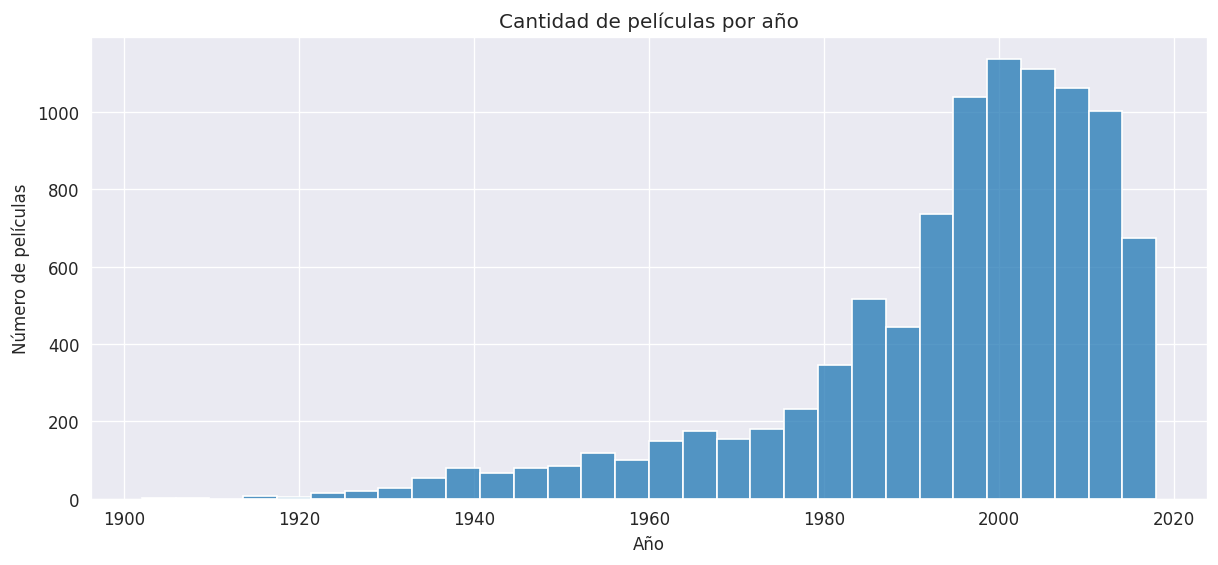

In [ ]:
csv_movies['release_year'] = pd.to_datetime(csv_movies['release_date'], errors='coerce').dt.year
plt.figure(figsize=(12,5))
sns.histplot(csv_movies['release_year'].dropna(), bins=30, kde=False)
plt.title('Cantidad de películas por año')
plt.xlabel('Año')
plt.ylabel('Número de películas')
plt.show()

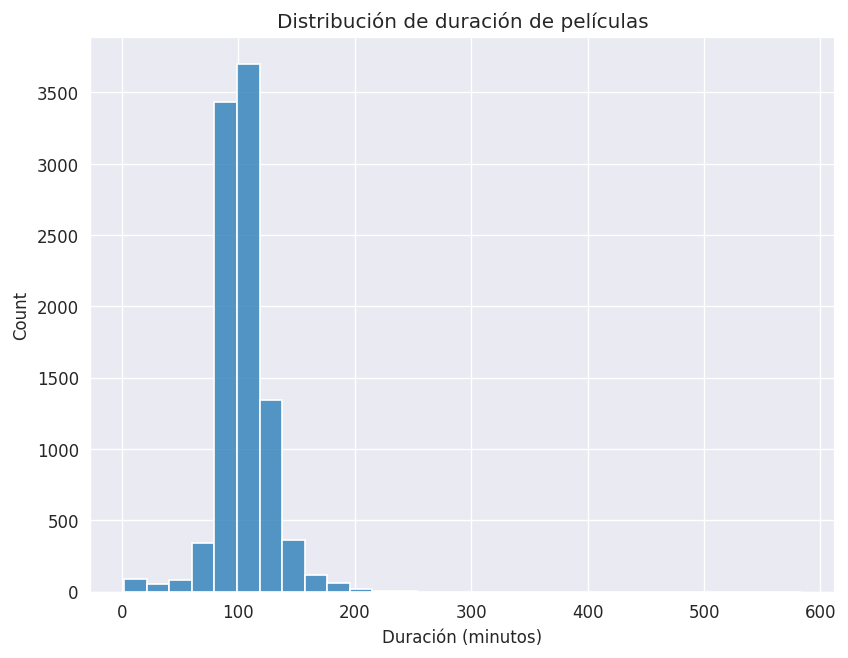

In [ ]:
sns.histplot(csv_movies['runtime'].dropna(), bins=30)
plt.title('Distribución de duración de películas')
plt.xlabel('Duración (minutos)')
plt.show()

count    100840.000000
mean          3.501567
std           1.042513
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


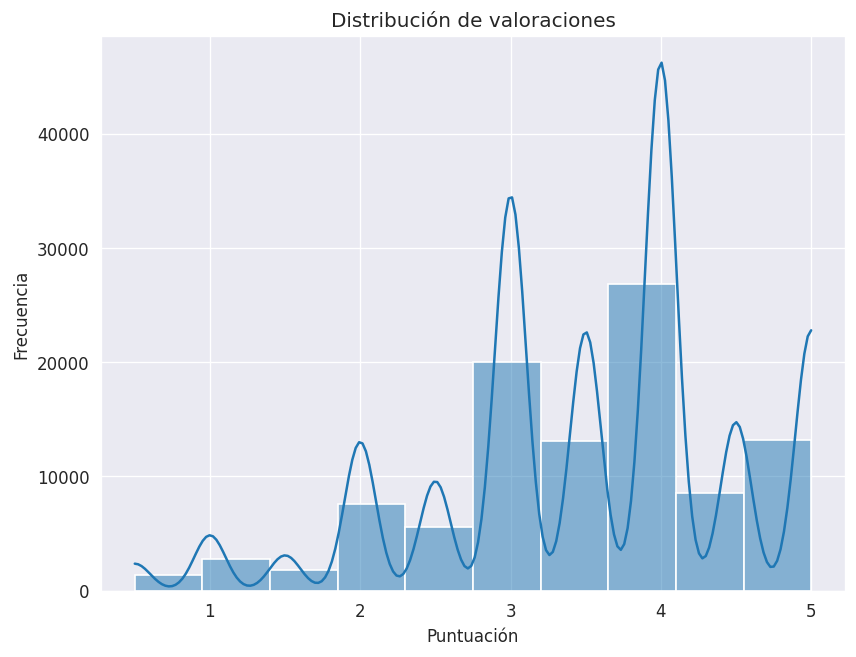

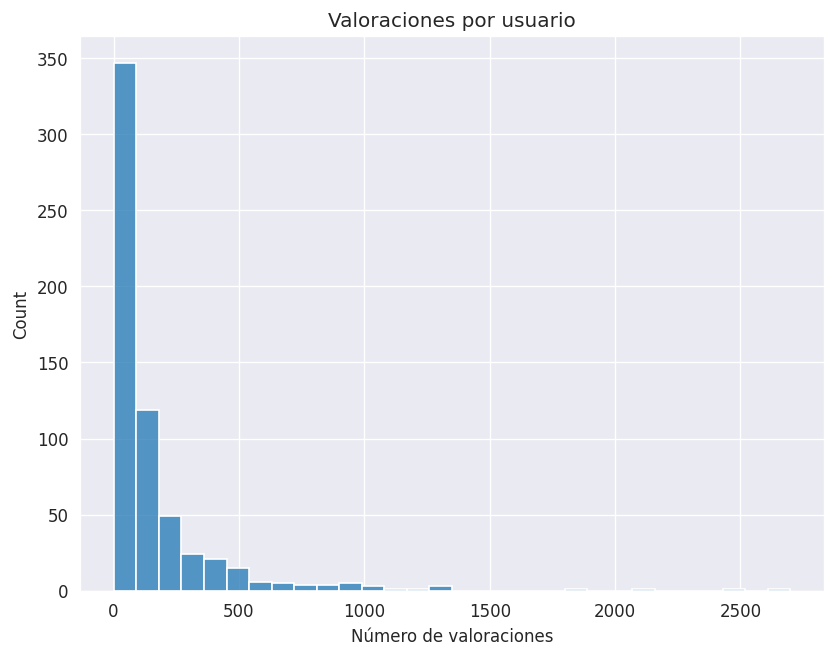

In [ ]:
# Estadísticas básicas
print(csv_ratings['rating'].describe())

# Distribución de puntuaciones
sns.histplot(csv_ratings['rating'], bins=10, kde=True)
plt.title('Distribución de valoraciones')
plt.xlabel('Puntuación')
plt.ylabel('Frecuencia')
plt.show()

# Valoraciones por usuario (nivel de actividad)
ratings_per_user = csv_ratings['user_id'].value_counts()
sns.histplot(ratings_per_user, bins=30)
plt.title('Valoraciones por usuario')
plt.xlabel('Número de valoraciones')
plt.show()

<Axes: title={'center': '🎭 Número de películas por género'}, xlabel='name'>

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


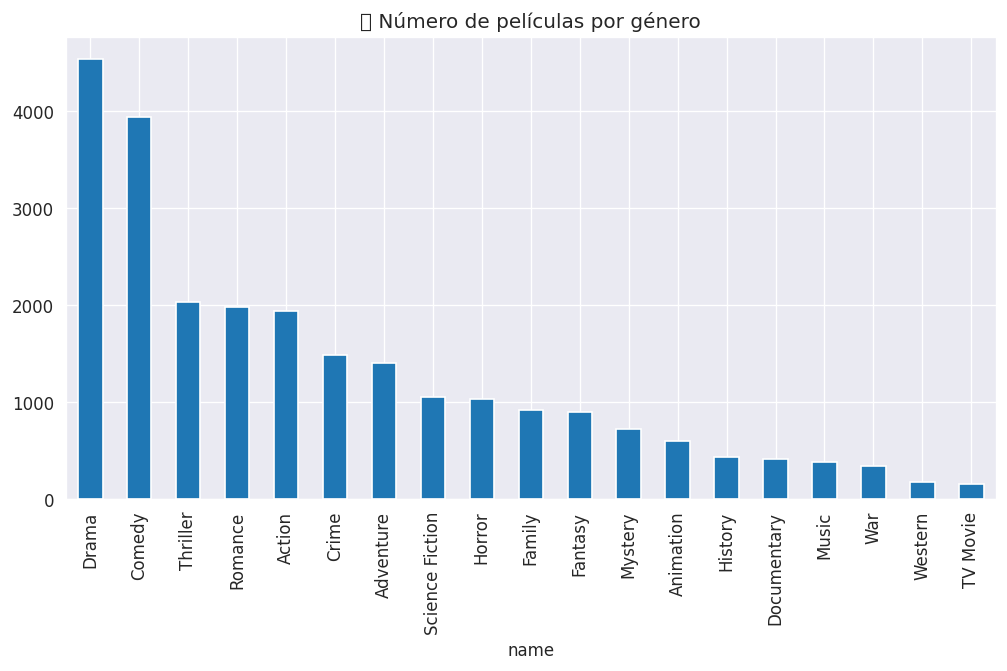

In [ ]:
df_genre_count = (
    csv_movie_ratings
    .merge(csv_genres, left_on="genre_id", right_on="id")
    .groupby("name")["movie_id"]
    .nunique()
    .sort_values(ascending=False)
)

df_genre_count.plot(kind="bar", figsize=(10, 5), title="🎭 Número de películas por género")

<Axes: title={'center': '⭐ Valoración promedio por género'}, xlabel='name'>

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


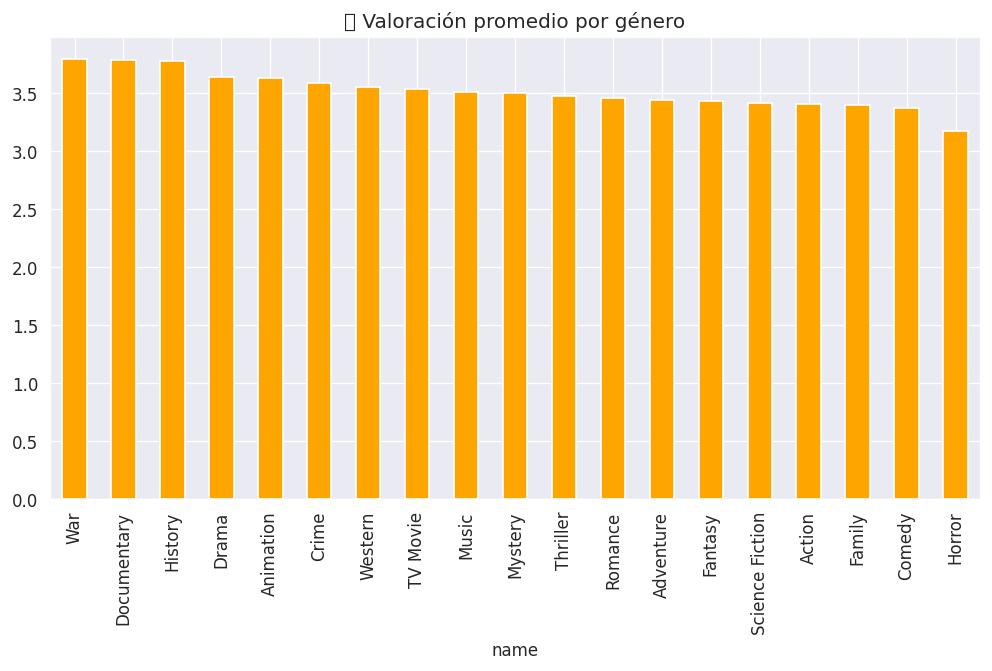

In [ ]:
df_ratings_with_genre = (
    csv_ratings
    .merge(csv_movie_ratings, on="movie_id")
    .merge(csv_genres, left_on="genre_id", right_on="id")
)

df_genre_avg_rating = (
    df_ratings_with_genre
    .groupby("name")["rating"]
    .mean()
    .sort_values(ascending=False)
)

df_genre_avg_rating.plot(kind="bar", figsize=(10, 5), color="orange", title="⭐ Valoración promedio por género")

In [ ]:
df_avg_ratings = (
    csv_ratings
    .groupby("movie_id")
    .agg(avg_rating=("rating", "mean"), count=("rating", "count"))
    .query("count >= 10")  # filtro: mínimo 10 valoraciones
    .reset_index()
    .merge(csv_movies[["movie_id", "title"]], on="movie_id")
    .sort_values(by="avg_rating", ascending=False)
)

print(df_avg_ratings.head(10))

      movie_id  avg_rating  count                           title
411       1041    4.590909     11                  Secrets & Lies
1186      3451    4.545455     11    Guess Who's Coming to Dinner
456       1178    4.541667     12                  Paths of Glory
441       1104    4.475000     20        A Streetcar Named Desire
871       2360    4.458333     12                 The Celebration
484       1217    4.433333     15                             Ran
158        318    4.426332    319        The Shawshank Redemption
377        951    4.392857     14                 His Girl Friday
722       1927    4.350000     10  All Quiet on the Western Front
1190      3468    4.333333     18                     The Hustler


<Axes: title={'center': '👤 Usuarios con más valoraciones'}, xlabel='user_id'>

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


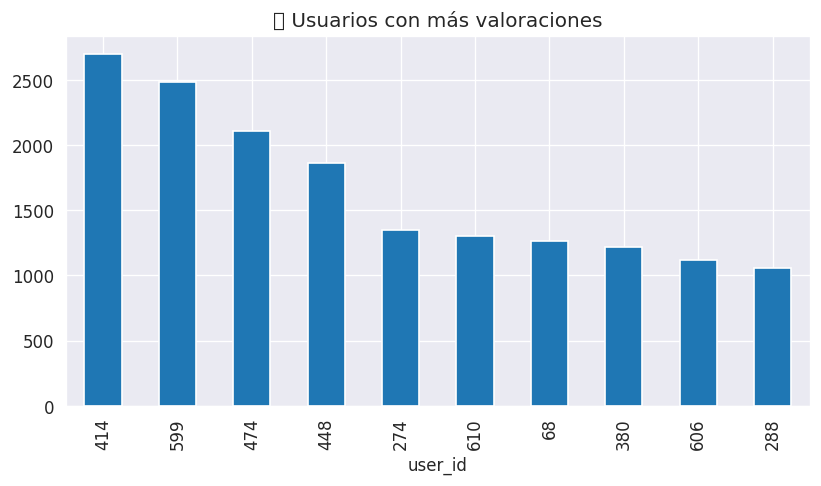

In [ ]:
df_top_users = (
    csv_ratings["user_id"]
    .value_counts()
    .head(10)
)

df_top_users.plot(kind="bar", figsize=(8, 4), title="👤 Usuarios con más valoraciones")

<Axes: title={'center': '👤 Usuarios con más valoraciones'}, xlabel='user_id'>

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


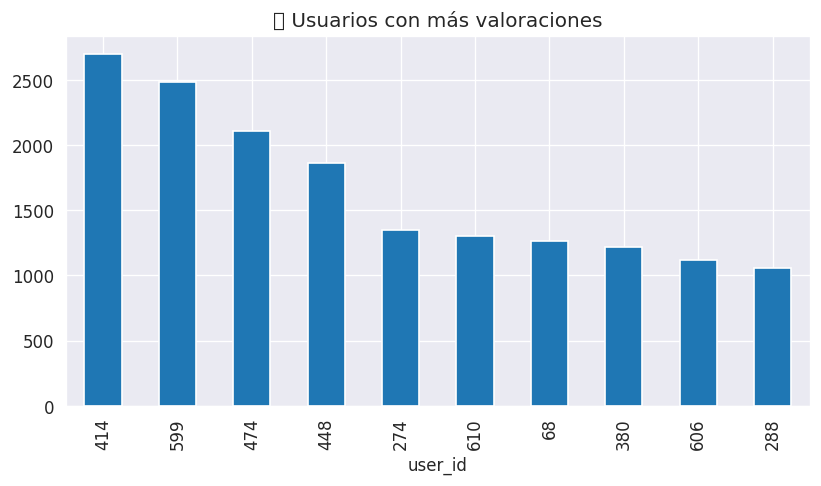

In [ ]:
df_top_views = (
    csv_user_views["user_id"]
    .value_counts()
    .head(10)
)

df_top_users.plot(kind="bar", figsize=(8, 4), title="👤 Usuarios con más peliculas vistas")

<ipython-input-31-5a46c3f3a216>:26: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


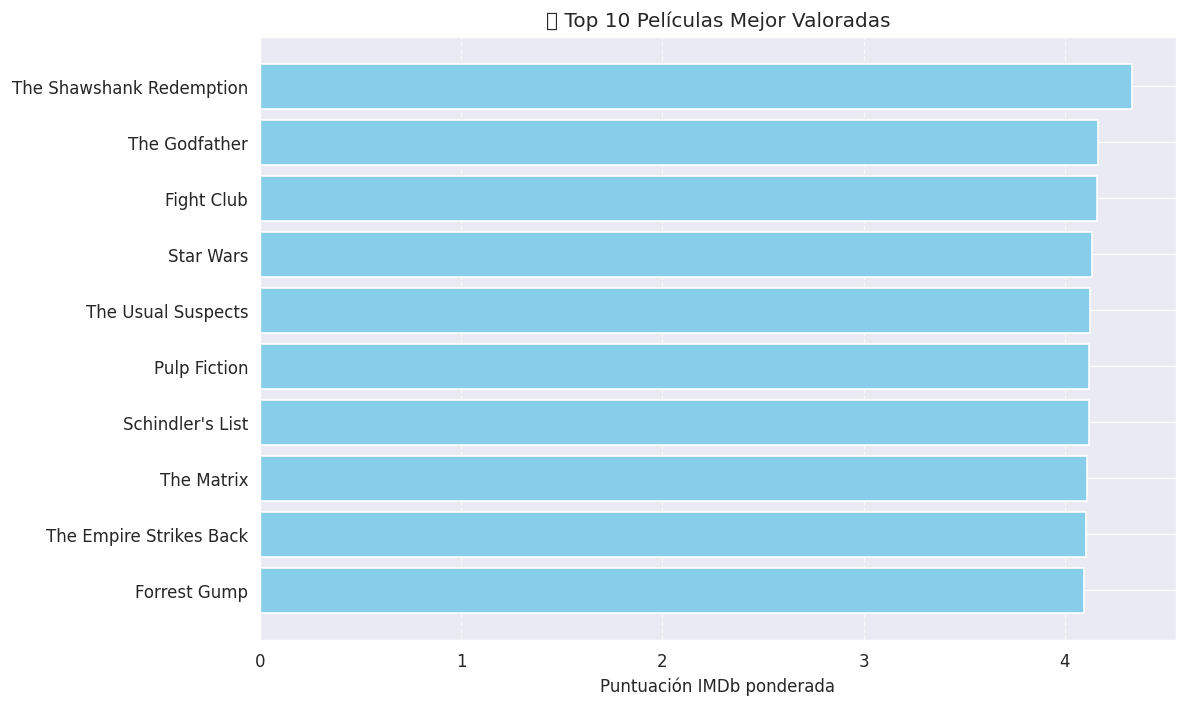

In [ ]:
movie_stats = (
    csv_ratings
    .groupby("movie_id")
    .agg(R=("rating", "mean"), v=("rating", "count"))
    .reset_index()
)

C = movie_stats["R"].mean()
m = movie_stats["v"].quantile(0.90)

qualified = movie_stats[movie_stats["v"] >= m].copy()
qualified["score"] = (
    (qualified["v"] / (qualified["v"] + m)) * qualified["R"] +
    (m / (qualified["v"] + m)) * C
)

qualified = qualified.merge(csv_movies[["movie_id", "title"]], on="movie_id")
top10 = qualified.sort_values(by="score", ascending=False).head(10)

# --- Gráfica ---
plt.figure(figsize=(10, 6))
plt.barh(top10["title"][::-1], top10["score"][::-1], color="skyblue")
plt.xlabel("Puntuación IMDb ponderada")
plt.title("🎬 Top 10 Películas Mejor Valoradas")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<ipython-input-36-1acaf8011bd2>:27: UserWarning: Glyph 127909 (\N{MOVIE CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127909 (\N{MOVIE CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


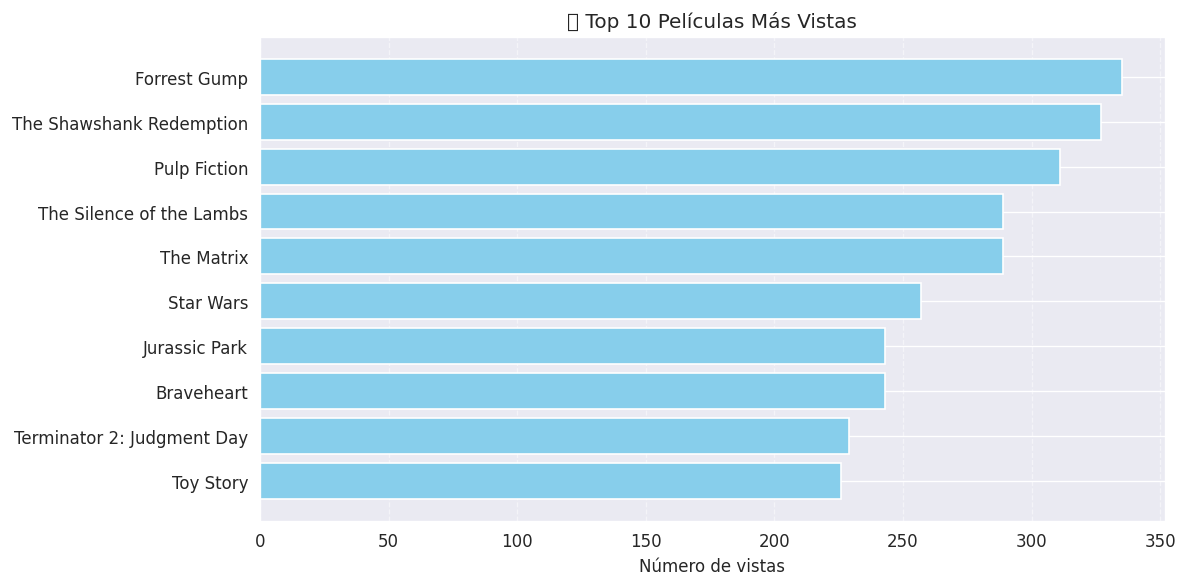

<ipython-input-36-1acaf8011bd2>:36: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


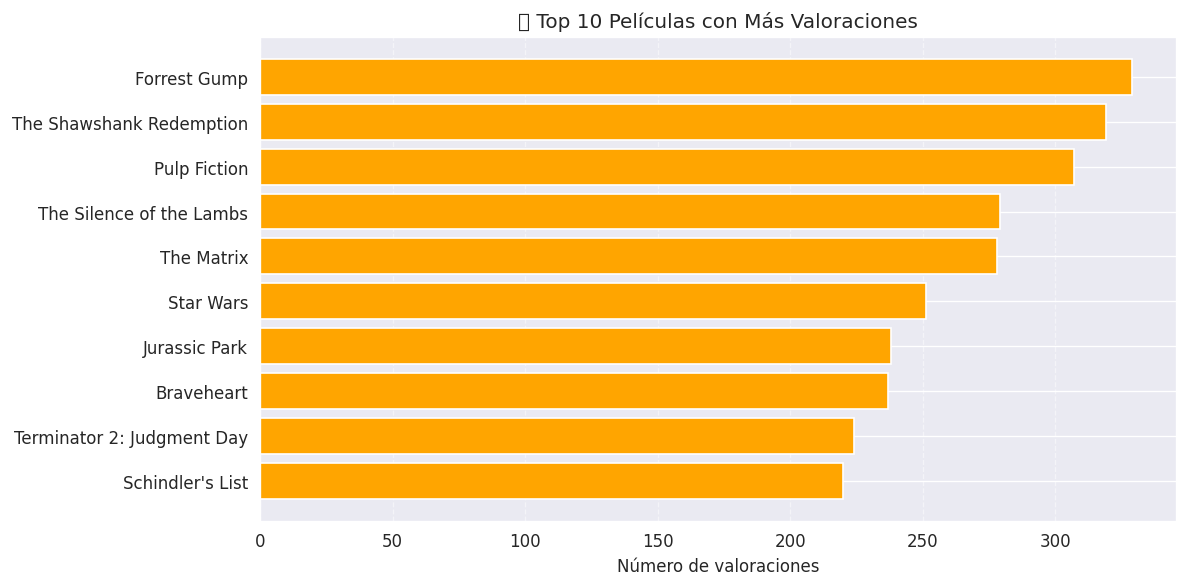

In [ ]:
# 1. 📊 Películas más vistas
views_count = (
    csv_user_views.groupby("movie_id")
    .agg(num_views=("user_id", "count"))
    .reset_index()
    .merge(csv_movies[["movie_id", "title"]], on="movie_id")
    .sort_values(by="num_views", ascending=False)
    .head(10)
)

# 2. ⭐ Películas con más valoraciones
ratings_count = (
    csv_ratings.groupby("movie_id")
    .agg(num_ratings=("user_id", "count"))
    .reset_index()
    .merge(csv_movies[["movie_id", "title"]], on="movie_id")
    .sort_values(by="num_ratings", ascending=False)
    .head(10)
)

# --- Gráfica 1: Más vistas ---
plt.figure(figsize=(10, 5))
plt.barh(views_count["title"][::-1], views_count["num_views"][::-1], color="skyblue")
plt.xlabel("Número de vistas")
plt.title("🎥 Top 10 Películas Más Vistas")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Gráfica 2: Más valoradas ---
plt.figure(figsize=(10, 5))
plt.barh(ratings_count["title"][::-1], ratings_count["num_ratings"][::-1], color="orange")
plt.xlabel("Número de valoraciones")
plt.title("⭐ Top 10 Películas con Más Valoraciones")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<ipython-input-33-20ceb1dd1bdd>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x="rating_to_view_ratio", y="title", palette="viridis")
<ipython-input-33-20ceb1dd1bdd>:36: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


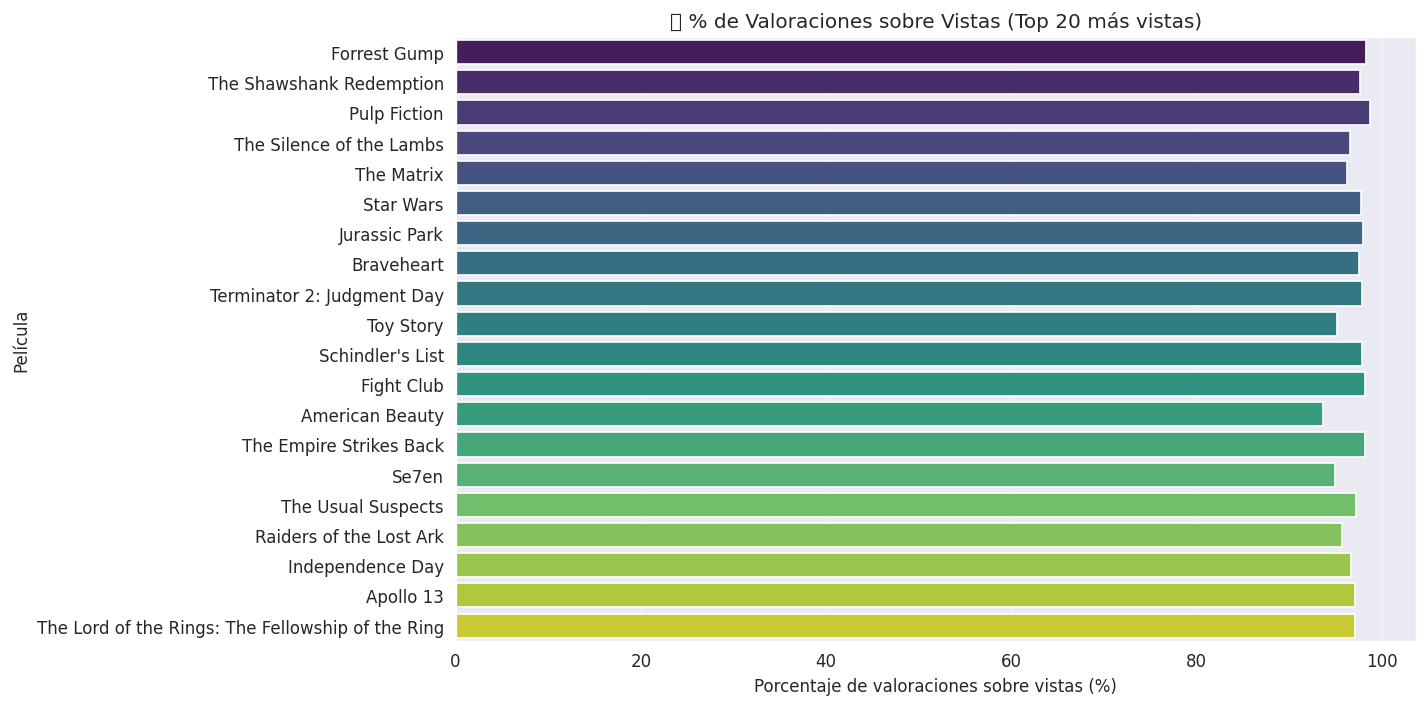

In [ ]:
views_count = (
    csv_user_views.groupby("movie_id")
    .agg(num_views=("user_id", "count"))
    .reset_index()
)

ratings_count = (
    csv_ratings.groupby("movie_id")
    .agg(num_ratings=("user_id", "count"))
    .reset_index()
)

# 🔗 Paso 2: Unir vistas y valoraciones
merged_stats = (
    views_count.merge(ratings_count, on="movie_id", how="left")
    .merge(csv_movies[["movie_id", "title"]], on="movie_id")
)

# Llenamos NaN en num_ratings (por si alguna peli nunca fue valorada)
merged_stats["num_ratings"] = merged_stats["num_ratings"].fillna(0)

# 🧮 Paso 3: Calcular porcentaje
merged_stats["rating_to_view_ratio"] = (merged_stats["num_ratings"] / merged_stats["num_views"]) * 100

# 🥇 Paso 4: Top 20 por vistas
top20 = merged_stats.sort_values(by="num_views", ascending=False).head(20)

# 📊 Paso 5: Gráfica
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(data=top20, x="rating_to_view_ratio", y="title", palette="viridis")
plt.xlabel("Porcentaje de valoraciones sobre vistas (%)")
plt.ylabel("Película")
plt.title("🎯 % de Valoraciones sobre Vistas (Top 20 más vistas)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

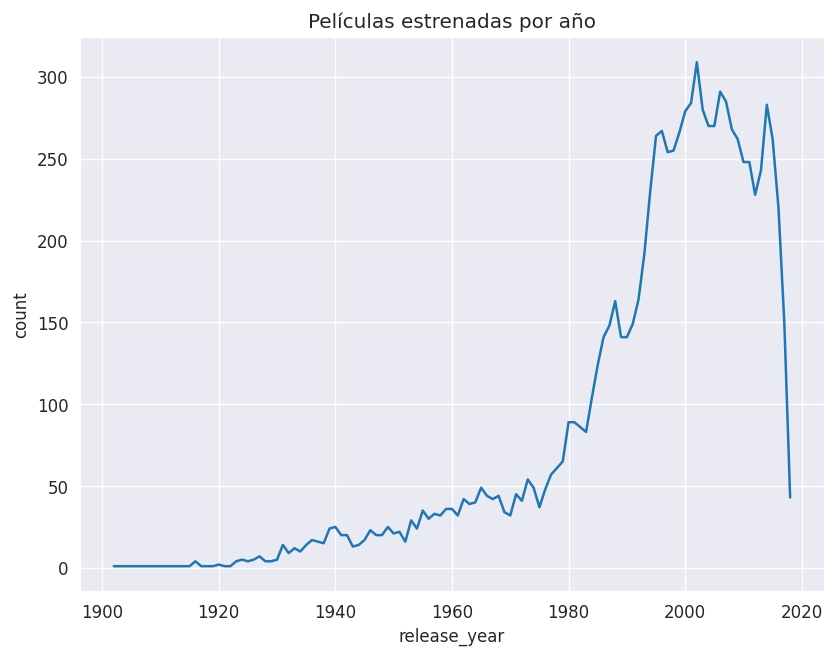

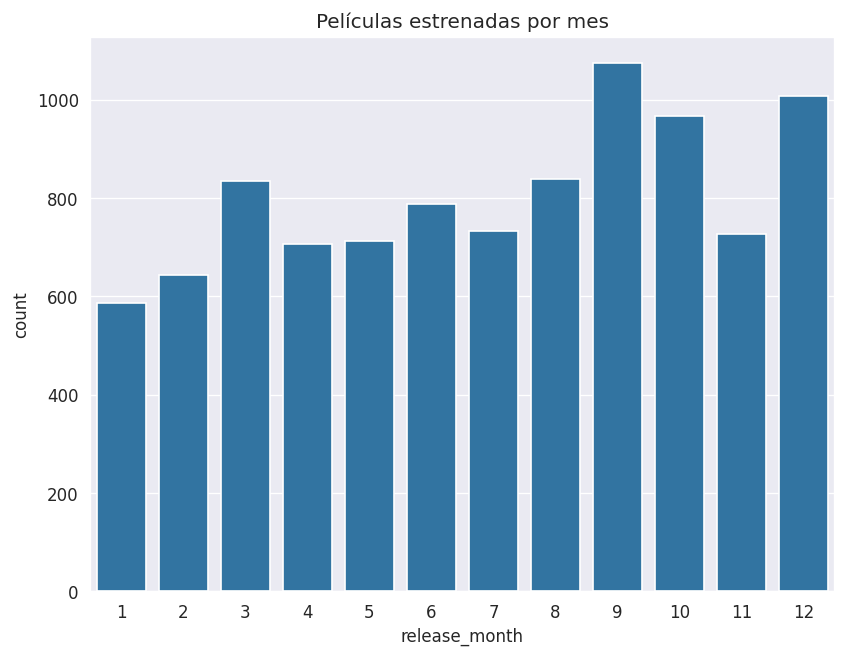

In [ ]:
csv_movies["release_date"] = pd.to_datetime(csv_movies["release_date"])
csv_movies["release_year"] = csv_movies["release_date"].dt.year
csv_movies["release_month"] = csv_movies["release_date"].dt.month

movies_per_year = csv_movies.groupby("release_year").size().reset_index(name="count")
movies_per_month = csv_movies.groupby("release_month").size().reset_index(name="count")

sns.lineplot(data=movies_per_year, x="release_year", y="count")
plt.title("Películas estrenadas por año")
plt.show()

sns.barplot(data=movies_per_month, x="release_month", y="count")
plt.title("Películas estrenadas por mes")
plt.show()